<a href="https://colab.research.google.com/github/joseph-2412/fisica-computacional-2026-02/blob/main/taller%20%5B%232%5D/(Criterios%20de%20parada%2C%20n%C3%BAmeros%20peque%C3%B1os-Python)%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#A
#1. Complete y depure suma_seno (sección 7, "B. Completar el algoritmo") si aún no lo ha hecho.

In [ ]:
def suma_seno(x, tol=1e-8, max_iter=200):
    term = x        # Primer término (n=0): t_0 = x
    total = x       # La suma empieza con el primer término
    n = 0

    for i in range(max_iter):
        n += 1

        #  Calculamos el nuevo término usando el anterior
        term = -term * (x**2) / ((2 * n) * (2 * n + 1))

        #  Acumulamos el término en la suma total
        total = total + term

        #  Verificamos si el término ya es tan pequeño que podemos parar
        if abs(term) < tol * max(1.0, abs(total)):
            break

    return total, i + 1

In [ ]:
#para comprabar si nos quedo bien
import math

# Probemos con x = 0.5
mi_resultado, iteraciones = suma_seno(0.5)
valor_exacto = math.sin(0.5)

print("Mi resultado:  ", mi_resultado)
print("Valor exacto:  ", valor_exacto)
print("Iteraciones:   ", iteraciones)

Mi resultado:   0.4794255386164159
Valor exacto:   0.479425538604203
Iteraciones:    4



#A2. Genere la tabla de convergencia (como en la sección 7) para al menos 6 valores de  x  entre  0  y  4π , incluyendo el número de iteraciones, la suma y el error relativo frente a **math**.sin.

In [ ]:
import math
import numpy as np

# Definimos 6 valores de x entre 0 y 4*pi
# Usamos un par de valores especiales como pi/2,  pi y 2*pi
valores_x = [1.0, math.pi / 2, math.pi, 5.0, 2 * math.pi, 10.0, 4 * math.pi]

# Imprimimos el encabezado de la tabla bonita
print(f"{'x':>10} | {'Suma Seno':>15} | {'math.sin(x)':>15} | {'Iteraciones':>11} | {'Error Relativo':>18}")
print("-" * 80)

#  Recorremos cada valor de x y calculamos los datos
for x in valores_x:
    # Nuestro cálculo
    mi_seno, iteraciones = suma_seno(x)

    # El valor exacto del módulo math
    exacto = math.sin(x)

    # Cálculo del error relativo (evitando división por cero si exacto es 0)
    if abs(exacto) > 1e-15:
        err_rel = abs(mi_seno - exacto) / abs(exacto)
    else:
        err_rel = abs(mi_seno - exacto)

    # Imprimimos la fila formateada
    print(f"{x:10.4f} | {mi_seno:15.8f} | {exacto:15.8f} | {iteraciones:11d} | {err_rel:18.4e}")

         x |       Suma Seno |     math.sin(x) | Iteraciones |     Error Relativo
--------------------------------------------------------------------------------
    1.0000 |      0.84147098 |      0.84147098 |           6 |         9.0549e-13
    1.5708 |      1.00000000 |      1.00000000 |           7 |         6.0232e-12
    3.1416 |      0.00000000 |      0.00000000 |          10 |         1.0348e-11
    5.0000 |     -0.95892427 |     -0.95892427 |          13 |         2.1394e-11
    6.2832 |     -0.00000000 |     -0.00000000 |          15 |         2.4379e-11
   10.0000 |     -0.54402111 |     -0.54402111 |          20 |         2.8886e-10
   12.5664 |      0.00000000 |     -0.00000000 |          24 |         6.8576e-11



#A3. Con los datos de la tabla del punto anterior, compare el error relativo de cada caso contra la tolerancia esperada  10−8 : ¿en todos los valores de  x  que probó el error relativo queda por debajo de esa tolerancia? Si en algún caso no es así, indique para cuáles valores de  x  ocurre y explique a qué se debe.

R: Si, como se observa en  la tabla los valores obtenidos del error relavito esta entre 10^-13 y 10^-10, como estos valores son menores que la  tolerancia esperada de tol = 10^-8, entonces esto nos dice que se confirma que el algoritmo cumple y nos da una mejor precision que la requerida


#
#A4. Repita el experimento de la sección 7 para  x  grande (por ejemplo,  x=100 ) sin la reducción de periodicidad, y explique en una o dos frases qué está pasando numéricamente.

R: Al calcular sin(100), la serie de Taylor falla, porque genera numeros tan grandes (de orden de 10^42) lo que hace que se olvida de los numeros mas pequeños, ademas cuando se restan numeros muy similares la computadora los proxima y nos da un resultado erroneo.  Haciendo que el calculo falle por completo. (como se puede observar en el codigo de abajo)

In [ ]:
import math

# Evaluamos x = 100 con nuestra función
x_grande = 100.0
mi_resultado, iteraciones = suma_seno(x_grande)
exacto = math.sin(x_grande)
error_abs = abs(mi_resultado - exacto)

print(f"Valor de x:               {x_grande}")
print(f"Resultado de suma_seno:   {mi_resultado}")
print(f"Resultado exacto (math):  {exacto}")
print(f"Número de iteraciones:    {iteraciones}")
print(f"Error absoluto:           {error_abs:.4e}")

Valor de x:               100.0
Resultado de suma_seno:   -8.261375671717164e+25
Resultado exacto (math):  -0.5063656411097588
Número de iteraciones:    111
Error absoluto:           8.2614e+25



#A5. Compare su implementación recursiva con una versión "ingenua" que calcule cada término desde cero usando `math.factorial` y `x**potencia` — ¿en qué valores de $x$ empieza a notarse la diferencia de desempeño o de precisión?

In [ ]:
import math # Importa el módulo math para calcular factoriales y comparar resultados.

#  Definición de la versión i(calcula factorial y potencia desde cero)
def suma_seno_ingenua(x, tol=1e-8, imax=200):
    suma = 0.0
    for n in range(imax):
        # Calcula el término completo desde cero en cada iteración
        termino = ((-1)**n) * (x**(2*n + 1)) / math.factorial(2*n + 1)
        suma += termino

        # Criterio de parada
        if abs(termino) < tol * max(1.0, abs(suma)):
            break

    return suma, n + 1

#  Imprimimos el encabezado de la tabla para comparar ambas versiones
print(f"{'x':>6} | {'Suma Rec':>15} | {'Suma Ing':>15} | {'Iters Rec':>10} | {'Iters Ing':>10}")
print("-" * 68)

#  Probamos con varios valores de x para observar dónde difieren
for x in [1.5, 5.0, 10.0, 20.0, 30.0]:
    approx_rec, inter_rec = suma_seno(x)
    approx_ing, inter_ing = suma_seno_ingenua(x)

    print(f"{x:6.1f} | {approx_rec:15.8f} | {approx_ing:15.8f} | {inter_rec:10d} | {inter_ing:10d}")

     x |        Suma Rec |        Suma Ing |  Iters Rec |  Iters Ing
--------------------------------------------------------------------
   1.5 |      0.99749499 |      0.99749499 |          7 |          8
   5.0 |     -0.95892427 |     -0.95892427 |         13 |         14
  10.0 |     -0.54402111 |     -0.54402111 |         20 |         21
  20.0 |      0.91294526 |      0.91294525 |         34 |         35
  30.0 |     -0.98807343 |     -0.98799986 |         48 |         49


R: Los valeres de x en que empizan a notarse la diferencia a partir de x = 20.0

# B.

# 1.   Calcule la constante de decaimiento $\lambda$


In [ ]:
import numpy as np
import math

#  Parámetros del problema
 # Vida media  5 años
t_mitad = 5.0

#  Cálculo de la constante lambda
lambda_const = math.log(2) / t_mitad

print(f"Vida media (t_1/2):              {t_mitad} años")
print(f"Constante de decaimiento (λ):   {lambda_const:.6f}1/año")

Vida media (t_1/2):              5.0 años
Constante de decaimiento (λ):   0.1386291/año




# B2.    Utilice `numpy.linspace()` para crear un arreglo de tiempos entre **0 y 30 años**. Utilice un número suficiente de puntos para observar claramente la evolución de la muestra



In [ ]:
import numpy as np # Importa NumPy para el manejo eficiente


# definimos el arreglo entre 0 a 30 años
# se utiliza el 200 para tener 200 puntos entre 0 a 30 para tener una curva continua
t = np.linspace(0, 30, 200)


# Imprimimos valores clave de control
print(f"Puntos generados:         {len(t)}")
print(f"Tiempo inicial: {t[0]} años | Tiempo final: {t[-1]} años")

Puntos generados:         200
Tiempo inicial: 0.0 años | Tiempo final: 30.0 años



#B3. Calcule $N(t)$ para todos los valores del arreglo de tiempos utilizando las operaciones vectorizadas de NumPy.

   **No utilice un ciclo `for` para realizar este cálculo.**

In [ ]:
import numpy as np # Importa NumPy para el manejo eficiente

#  Parámetros del modelo de decaimiento
N0 = 10000.0 # Masa inicial
t_mitad = 5.0 # Vida media (5 años)
lambda_const = np.log(2) / t_mitad # Constante de decaimiento λ

#  Cálculo de la masa residual N(t) de forma vectorizada (sin ciclos for)
N_t = N0 * np.exp(-lambda_const * t)

# Imprimimos valores clave de control
print(f"Masa inicial (t = 0):      {N_t[0]:.2f}")
print(f"Masa a los 5 años (t_1/2): {N0 * np.exp(-lambda_const * 5):.2f}")
print(f"Masa final (t = 30):       {N_t[-1]:.4f}")

Masa inicial (t = 0):      10000.00
Masa a los 5 años (t_1/2): 5000.00
Masa final (t = 30):       156.2500



#B4. Utilice `matplotlib` para representar gráficamente $N(t)$ en función del tiempo. La gráfica debe incluir:

   - título;
   - nombre de los ejes;
   - unidades;
   - una cuadrícula que facilite la lectura de los resultados.


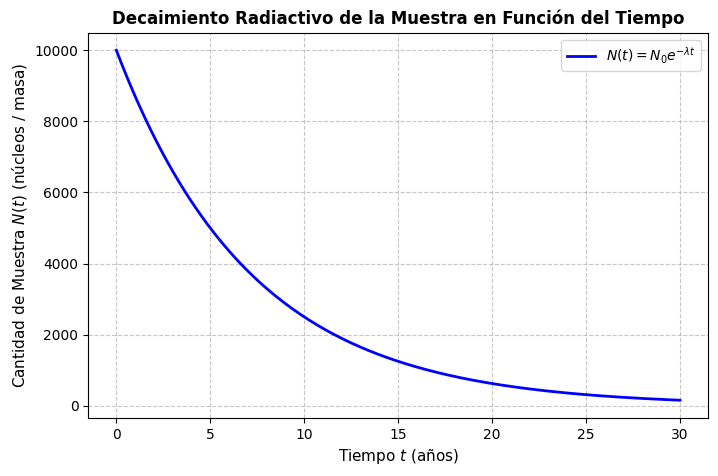

In [ ]:
import matplotlib.pyplot as plt # Importa el módulo de graficación de Matplotlib

#  Configuración del tamaño de la figura
plt.figure(figsize=(8, 5))

#  Graficar la función de decaimiento N(t)
plt.plot(t, N_t, color='blue', linewidth=2, label=r'$N(t) = N_0 e^{-\lambda t}$')

# 3. Título del gráfico
plt.title('Decaimiento Radiactivo de la Muestra en Función del Tiempo', fontsize=12, fontweight='bold')

#  Nombre de los ejes con las unidades
plt.xlabel('Tiempo $t$ (años)', fontsize=11)
plt.ylabel('Cantidad de Muestra $N(t)$ (núcleos / masa)', fontsize=11)

# cuadriculas de guia para hacer mas facil la lectura de la grafica
plt.grid(True, linestyle='--', alpha=0.7)

#  Leyenda informativa
plt.legend(loc='upper right', fontsize=10)

# graficar
plt.show()


# #B5. Identifique sobre la gráfica los tiempos correspondientes a **una, dos y tres vidas medias**. Observe qué fracción de la muestra permanece después de cada una de ellas.

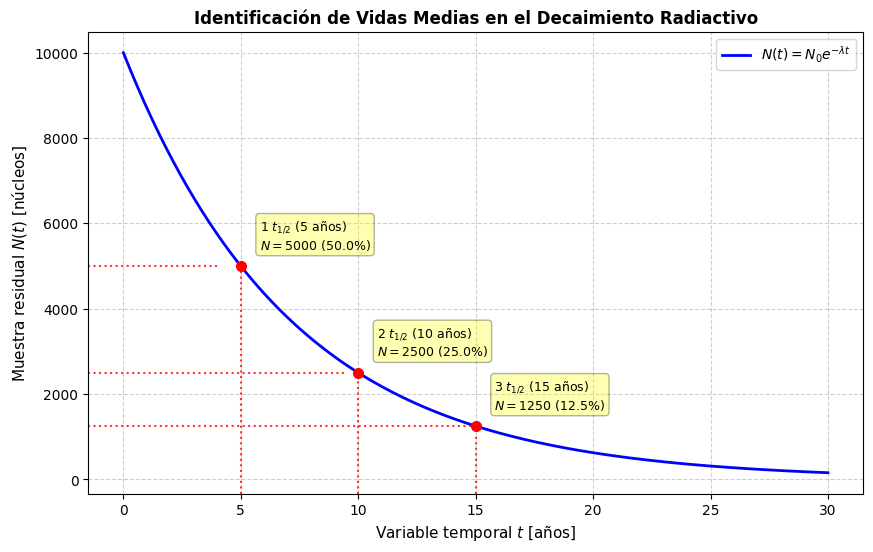

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de la figura
plt.figure(figsize=(10, 6))

# 2. Graficamos la curva continua N(t)
plt.plot(t, N_t, color='blue', linewidth=2, label=r'$N(t) = N_0 e^{-\lambda t}$')

# 3. Definimos las 1, 2 y 3 vidas medias
vidas_medias = [1, 2, 3]
tiempos_vm = [k * t_mitad for k in vidas_medias] # [5.0, 10.0, 15.0] años

# 4. Marcamos los puntos sobre la gráfica con un ciclo
for k, t_k in zip(vidas_medias, tiempos_vm):
    N_k = N0 * np.exp(-lambda_const * t_k)

    # Dibujamos líneas discontinuas proyectadas hacia los ejes
    plt.axvline(x=t_k, ymax=N_k/N0, color='red', linestyle=':', alpha=0.8)
    plt.axhline(y=N_k, xmax=t_k/30, color='red', linestyle=':', alpha=0.8)

    # Dibujamos un punto rojo sobre la curva
    plt.plot(t_k, N_k, 'ro', markersize=7)

    # Añadimos un texto indicando la fracción restante
    fraccion = (1/2)**k
    plt.annotate(f'{k} $t_{{1/2}}$ ({t_k:.0f} años)\n$N = {N_k:.0f}$ ({fraccion*100:.1f}%)',
                 xy=(t_k, N_k),
                 xytext=(t_k + 0.8, N_k + 400),
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# 5. Etiquetas, título y formato de la gráfica
plt.title('Identificación de Vidas Medias en el Decaimiento Radiactivo', fontsize=12, fontweight='bold')
plt.xlabel('Variable temporal $t$ [años]', fontsize=11)
plt.ylabel('Muestra residual $N(t)$ [núcleos]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.show()


#B6. Determine aproximadamente el tiempo en el cual permanece:

   - el **50 %** de la muestra inicial;
   - el **25 %** de la muestra inicial;
   - el **10 %** de la muestra inicial.

In [ ]:
import numpy as np

# Porcentajes requeridos (expresados como fracción)
porcentajes = [0.50, 0.25, 0.10]

print("=== TIEMPOS ESTIMADOS PARA CADA PORCENTAJE DE MUESTRA RESIDUAL ===")

for p in porcentajes:
    # Cálculo analítico exacto despejando t
    t_exacto = -np.log(p) / lambda_const

    # Búsqueda aproximada en nuestro arreglo numérico t
    indice_cercano = np.argmin(np.abs((N_t / N0) - p))
    t_aprox = t[indice_cercano]

    print(f"• Para el {int(p*100)}% de la muestra inicial ({int(N0*p)} núcleos):")
    print(f"  - Tiempo analítico (fórmula): {t_exacto:.2f} años")
    print(f"  - Tiempo aproximado (arreglo): {t_aprox:.2f} años\n")

=== TIEMPOS ESTIMADOS PARA CADA PORCENTAJE DE MUESTRA RESIDUAL ===
• Para el 50% de la muestra inicial (5000 núcleos):
  - Tiempo analítico (fórmula): 5.00 años
  - Tiempo aproximado (arreglo): 4.97 años

• Para el 25% de la muestra inicial (2500 núcleos):
  - Tiempo analítico (fórmula): 10.00 años
  - Tiempo aproximado (arreglo): 9.95 años

• Para el 10% de la muestra inicial (1000 núcleos):
  - Tiempo analítico (fórmula): 16.61 años
  - Tiempo aproximado (arreglo): 16.58 años



### C. Celda de verificación (PASS/FAIL)

Para agilizar la revisión, la tarea debe cerrar con una celda que compruebe automáticamente 2-3 casos conocidos e imprima PASS/FAIL — no hace falta rastrear la lógica a mano para calificar. Abajo hay una celda de verificación para la Parte A (usa `suma_seno_reducida`, ya definida en la sección 7) y una plantilla para la Parte B: complete `N_decaimiento` con $N(t) = N_0 e^{-\lambda t}$ y la celda le dirá si sus resultados coinciden con los valores esperados (recordando el caso de la vida media del carbono-14 de la Semana 1: al cabo de una vida media siempre queda el 50 % de la muestra).

In [ ]:
import numpy as np

#  Definición de la función de decaimiento requerida por la prueba
def N_decaimiento(t, N0, t_mitad):
    """
    Calcula la muestra residual N(t) dada la masa inicial N0 y la vida media t_mitad.
    """
    lambda_val = np.log(2) / t_mitad
    return N0 * np.exp(-lambda_val * t)

# Pruebas de verificación automática (PASS / FAIL)
def verificar_parte_B():
    errores = 0

    # Caso 1: t = 0 (Debe retornar exactamente N0)
    res_1 = N_decaimiento(0, 10000, 5)
    if np.isclose(res_1, 10000.0):
        print("[PASS] Caso 1: En t = 0 la muestra es N0 (10000)")
    else:
        print(f"[FAIL] Caso 1: Esperado 10000, obtenido {res_1}")
        errores += 1

    # Caso 2: t = t_1/2 (Al cabo de 1 vida media debe quedar el 50%)
    res_2 = N_decaimiento(5, 10000, 5)
    if np.isclose(res_2, 5000.0):
        print("[PASS] Caso 2: En t = 1 vida media queda el 50% (5000)")
    else:
        print(f"[FAIL] Caso 2: Esperado 5000, obtenido {res_2}")
        errores += 1

    # Caso 3: Carbono-14 (Semana 1) con t_1/2 = 5730 años, t = 11460 años (2 vidas medias -> 25%)
    res_3 = N_decaimiento(11460, 100, 5730)
    if np.isclose(res_3, 25.0):
        print("[PASS] Caso 3: C-14 a 2 vidas medias (11460 años) queda el 25%")
    else:
        print(f"[FAIL] Caso 3: Esperado 25.0, obtenido {res_3}")
        errores += 1

    print("-" * 50)
    if errores == 0:
        print("RESULTADO PARTE B: PASS (Todas las comprobaciones superadas correctamente)")
    else:
        print(f"RESULTADO PARTE B: FAIL ({errores} comprobaciones fallaron)")

# Ejecutar la verificación
verificar_parte_B()

[PASS] Caso 1: En t = 0 la muestra es N0 (10000)
[PASS] Caso 2: En t = 1 vida media queda el 50% (5000)
[PASS] Caso 3: C-14 a 2 vidas medias (11460 años) queda el 25%
--------------------------------------------------
RESULTADO PARTE B: PASS (Todas las comprobaciones superadas correctamente)
